In [24]:
!pip install pandas numpy scikit-learn seaborn matplotlib openpyxl

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [4]:
from google.colab import files
uploaded = files.upload()

Saving dataset 2.xlsx to dataset 2 (1).xlsx


In [5]:
df = pd.read_excel("dataset 2.xlsx")
df.head()

,Age,Gender,Height_cm,Weight_kg,BMI,Training_Frequency,Training_Duration,Warmup_Time,Sleep_Hours,Flexibility_Score,Muscle_Asymmetry,Recovery_Time,Injury_History,Stress_Level,Training_Intensity,Injury_Risk
0,36,0,155.4,56.3,23.34,1,94,20,7.2,63.3,3.7,63,1,8,4.4,0
1,30,0,167.6,45.3,16.12,4,114,5,7.1,64.6,5.1,64,1,7,6.7,0
2,21,1,176.7,60.8,19.48,1,95,11,5.0,68.6,6.1,69,0,6,4.3,1
3,37,0,170.2,60.7,20.97,5,73,6,8.1,69.0,4.6,65,2,3,6.4,1
4,30,0,161.5,45.0,17.25,6,93,8,7.8,45.2,8.5,42,3,8,4.2,1


In [6]:
print("Dataset Shape:", df.shape)

df.info()

df.describe()

Dataset Shape: (600, 16)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 600 non-null    int64  
 1   Gender              600 non-null    int64  
 2   Height_cm           600 non-null    float64
 3   Weight_kg           600 non-null    float64
 4   BMI                 600 non-null    float64
 5   Training_Frequency  600 non-null    int64  
 6   Training_Duration   600 non-null    int64  
 7   Warmup_Time         600 non-null    int64  
 8   Sleep_Hours         600 non-null    float64
 9   Flexibility_Score   600 non-null    float64
 10  Muscle_Asymmetry    600 non-null    float64
 11  Recovery_Time       600 non-null    int64  
 12  Injury_History      600 non-null    int64  
 13  Stress_Level        600 non-null    int64  
 14  Training_Intensity  600 non-null    float64
 15  Injury_Risk         600 non-null

,Age,Gender,Height_cm,Weight_kg,BMI,Training_Frequency,Training_Duration,Warmup_Time,Sleep_Hours,Flexibility_Score,Muscle_Asymmetry,Recovery_Time,Injury_History,Stress_Level,Training_Intensity,Injury_Risk
count,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000
mean,29.053333,0.441667,168.091167,62.816000,22.185433,3.495000,83.180000,9.988333,7.242333,60.232000,5.097333,74.598333,0.605000,5.498333,5.510167,0.315000
std,6.406160,0.497000,8.478391,11.608189,3.457063,1.692557,21.441482,6.186705,0.785198,10.098983,2.848435,26.545020,0.858411,2.912754,1.789754,0.464903
min,18.000000,0.000000,150.000000,45.000000,12.660000,1.000000,45.000000,0.000000,5.000000,30.500000,0.000000,30.000000,0.000000,1.000000,1.000000,0.000000
25%,24.000000,0.000000,161.475000,54.000000,19.720000,2.000000,66.000000,5.000000,6.700000,53.400000,3.100000,52.000000,0.000000,3.000000,4.300000,0.000000
50%,29.000000,0.000000,167.300000,61.200000,22.085000,3.000000,82.000000,10.000000,7.300000,60.350000,5.000000,75.000000,0.000000,5.000000,5.500000,0.000000
75%,34.000000,1.000000,174.725000,70.925000,24.390000,5.000000,101.000000,15.000000,7.800000,66.925000,7.000000,98.250000,1.000000,8.000000,6.800000,1.000000
max,40.000000,1.000000,190.000000,95.000000,33.550000,6.000000,120.000000,20.000000,9.500000,94.600000,14.400000,119.000000,3.000000,10.000000,10.000000,1.000000


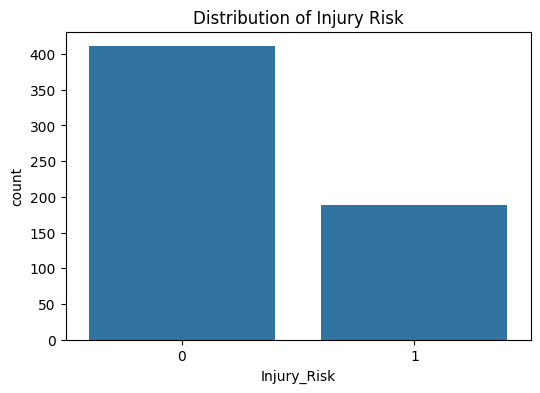

In [7]:
plt.figure(figsize=(6,4))
sns.countplot(x='Injury_Risk', data=df)
plt.title("Distribution of Injury Risk")
plt.show()

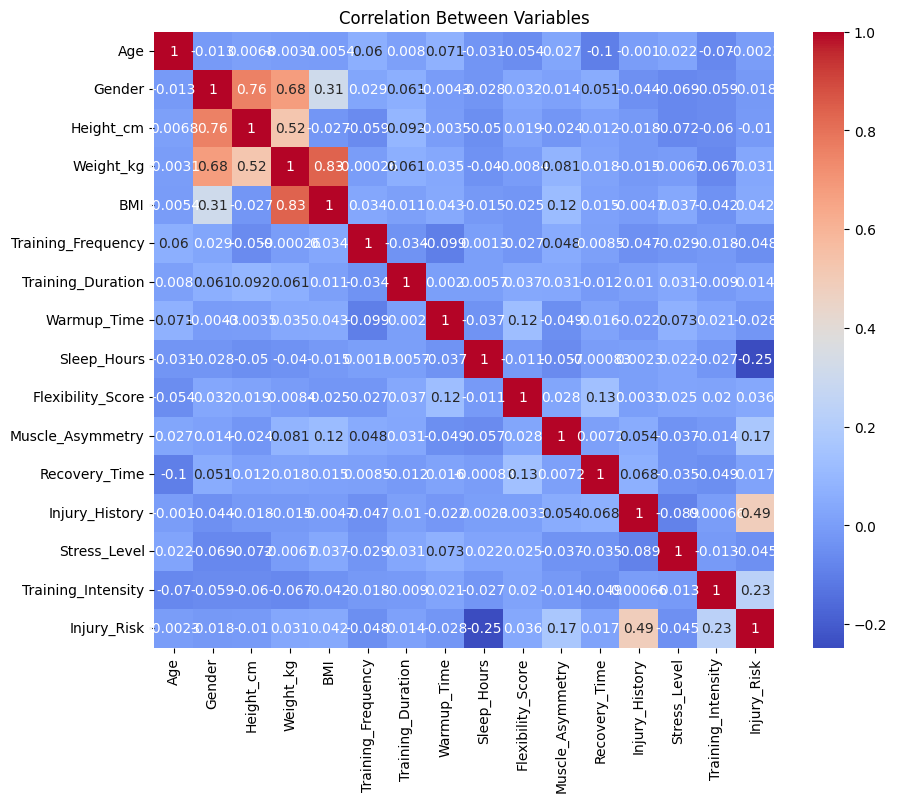

In [8]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Between Variables")
plt.show()

In [9]:
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

In [10]:
X = df.drop("Injury_Risk", axis=1)
y = df["Injury_Risk"]

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [12]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [13]:
lr = LogisticRegression()

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Logistic Regression Accuracy:",
      accuracy_score(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.8166666666666667


In [14]:
rf = RandomForestClassifier(n_estimators=100)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:",
      accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy: 0.9666666666666667


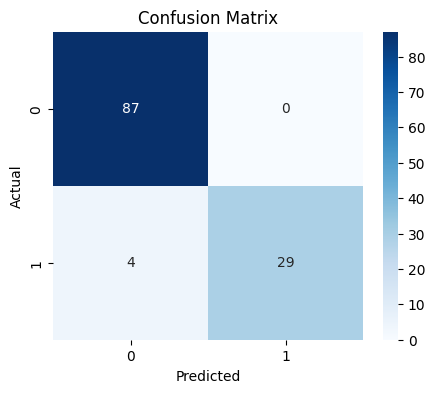

In [15]:
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

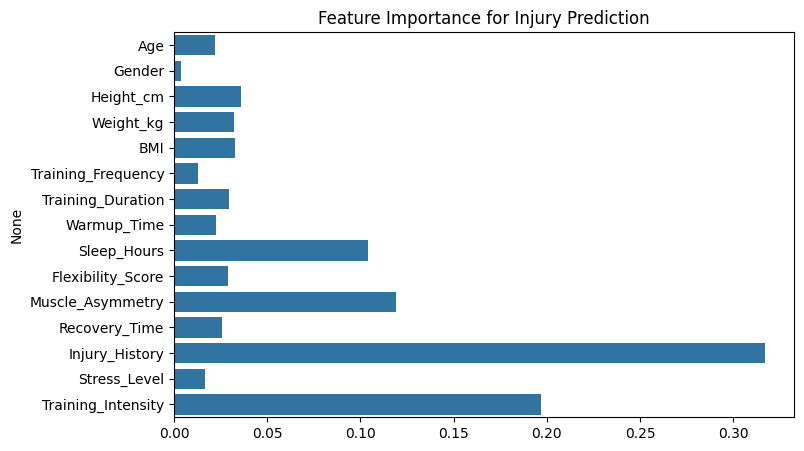

In [16]:
importance = rf.feature_importances_

features = X.columns

plt.figure(figsize=(8,5))
sns.barplot(x=importance, y=features)
plt.title("Feature Importance for Injury Prediction")
plt.show()

In [17]:
kmeans = KMeans(n_clusters=3)

clusters = kmeans.fit_predict(X)

df["Cluster"] = clusters

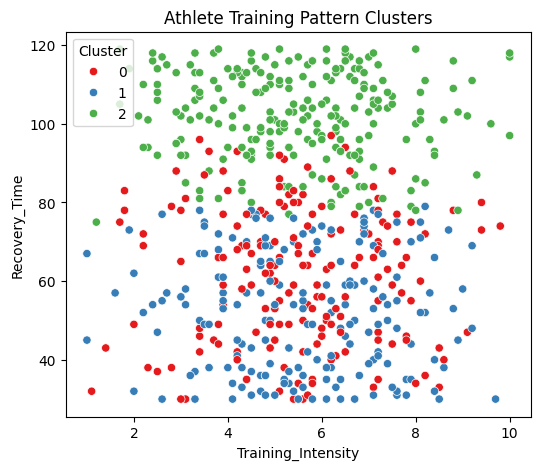

In [18]:
plt.figure(figsize=(6,5))

sns.scatterplot(
    x=df["Training_Intensity"],
    y=df["Recovery_Time"],
    hue=df["Cluster"],
    palette="Set1"
)

plt.title("Athlete Training Pattern Clusters")
plt.show()

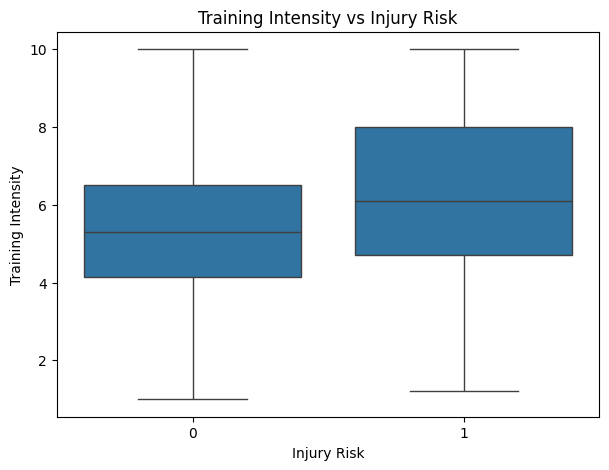

In [19]:
plt.figure(figsize=(7,5))
sns.boxplot(x='Injury_Risk', y='Training_Intensity', data=df)

plt.title("Training Intensity vs Injury Risk")
plt.xlabel("Injury Risk")
plt.ylabel("Training Intensity")

plt.show()

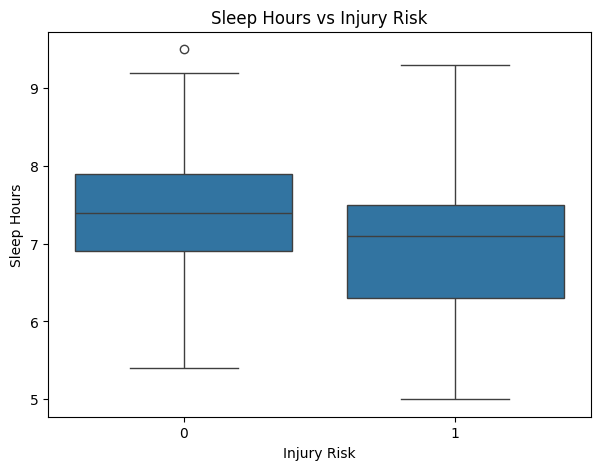

In [20]:
plt.figure(figsize=(7,5))
sns.boxplot(x='Injury_Risk', y='Sleep_Hours', data=df)

plt.title("Sleep Hours vs Injury Risk")
plt.xlabel("Injury Risk")
plt.ylabel("Sleep Hours")

plt.show()

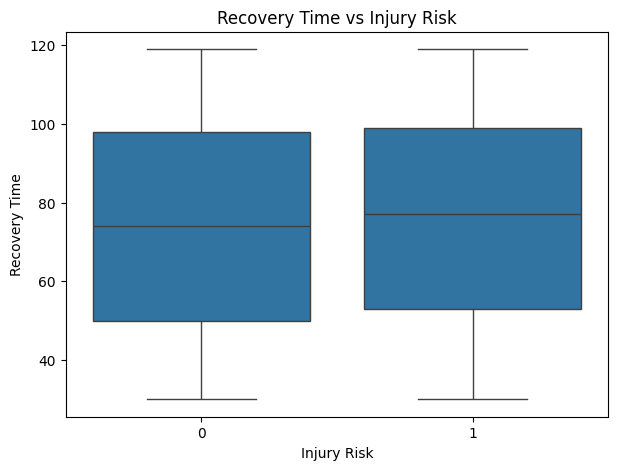

In [21]:
plt.figure(figsize=(7,5))
sns.boxplot(x='Injury_Risk', y='Recovery_Time', data=df)

plt.title("Recovery Time vs Injury Risk")
plt.xlabel("Injury Risk")
plt.ylabel("Recovery Time")

plt.show()

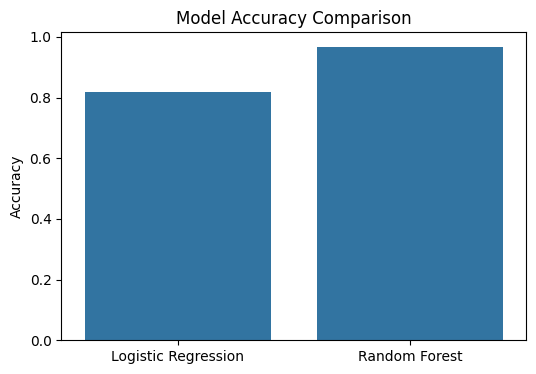

In [23]:
models = ["Logistic Regression", "Random Forest"]
accuracy = [
    accuracy_score(y_test, y_pred_lr),
    accuracy_score(y_test, y_pred_rf)
]

plt.figure(figsize=(6,4))
sns.barplot(x=models, y=accuracy)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")

plt.show()

In [25]:
# ================================
# Example Injury Risk Prediction
# ================================
sample = X_test[0].reshape(1, -1)

prediction = rf.predict(sample)
probability = rf.predict_proba(sample)

print("\nExample Prediction:")
print("Predicted Injury Risk:", prediction)
print("Probability:", probability)


Example Prediction:
Predicted Injury Risk: [1]
Probability: [[0.15 0.85]]


This method returns the probability of the sample belonging to each class. For an injury risk prediction, it will give two probabilities: one for class 0 (no injury risk) and one for class 1 (injury risk). For example, [[0.15 0.85]] means there's a 15% chance of no injury risk and an 85% chance of injury risk.